In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("18100204.csv")
df.head()

,REF_DATE,GEO,DGUID,Index,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2016A000011124,"Electric power selling price indexes, national...","Index, 2014=100",351,units,0,v107792869,1.1,31.0,NaN,NaN,NaN,1
1,1981-01,Canada,2016A000011124,Electric power selling price over 5000kw,"Index, 2014=100",351,units,0,v107792870,1.2,31.1,NaN,NaN,NaN,1
2,1981-01,Canada,2016A000011124,Electric power selling price under 5000kw,"Index, 2014=100",351,units,0,v107792871,1.3,30.8,NaN,NaN,NaN,1
3,1981-01,Atlantic Region,2016A00011,Electric power selling price over 5000kw,"Index, 2014=100",351,units,0,v107792873,2.2,38.2,NaN,NaN,NaN,1
4,1981-01,Atlantic Region,2016A00011,Electric power selling price under 5000kw,"Index, 2014=100",351,units,0,v107792874,2.3,45.2,NaN,NaN,NaN,1


In [5]:
df['REF_DATE'] = pd.to_datetime(df['REF_DATE'], format="%Y-%M").dt.to_period('M')
df.head()

,REF_DATE,GEO,DGUID,Index,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2016A000011124,"Electric power selling price indexes, national...","Index, 2014=100",351,units,0,v107792869,1.1,31.0,NaN,NaN,NaN,1
1,1981-01,Canada,2016A000011124,Electric power selling price over 5000kw,"Index, 2014=100",351,units,0,v107792870,1.2,31.1,NaN,NaN,NaN,1
2,1981-01,Canada,2016A000011124,Electric power selling price under 5000kw,"Index, 2014=100",351,units,0,v107792871,1.3,30.8,NaN,NaN,NaN,1
3,1981-01,Atlantic Region,2016A00011,Electric power selling price over 5000kw,"Index, 2014=100",351,units,0,v107792873,2.2,38.2,NaN,NaN,NaN,1
4,1981-01,Atlantic Region,2016A00011,Electric power selling price under 5000kw,"Index, 2014=100",351,units,0,v107792874,2.3,45.2,NaN,NaN,NaN,1


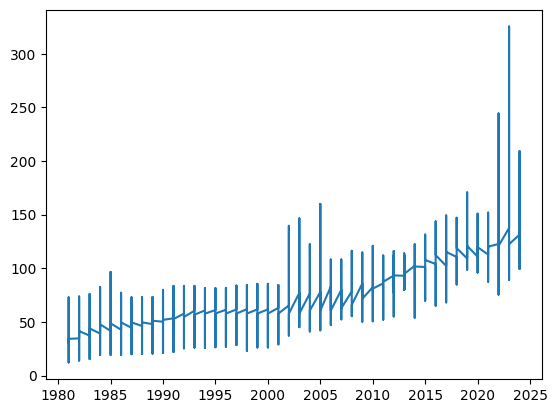

In [6]:
plt.plot(df['REF_DATE'].dt.to_timestamp(), df['VALUE'])


In [7]:


df_clean = df[df['GEO'] == "Alberta"]


In [8]:
df_clean['VALUE'] = df_clean['VALUE'].interpolate(method='linear')

/tmp/ipykernel_9214/3801703493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['VALUE'] = df_clean['VALUE'].interpolate(method='linear')


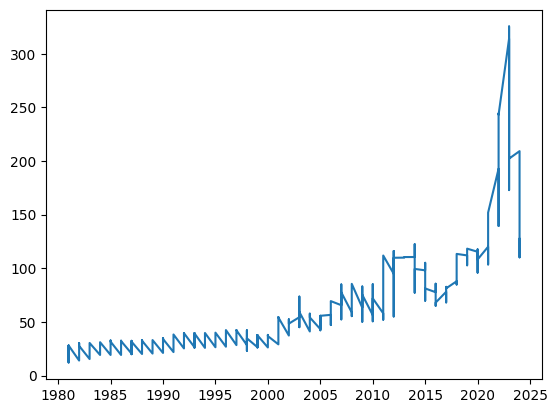

In [9]:
plt.plot(df_clean['REF_DATE'].dt.to_timestamp(), df_clean['VALUE'])


In [10]:
from scipy.signal import savgol_filter
df_clean['VALUE_SMOOTH'] = savgol_filter(df_clean['VALUE'], window_length=10, polyorder=2)

/tmp/ipykernel_9214/3886491061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['VALUE_SMOOTH'] = savgol_filter(df_clean['VALUE'], window_length=10, polyorder=2)


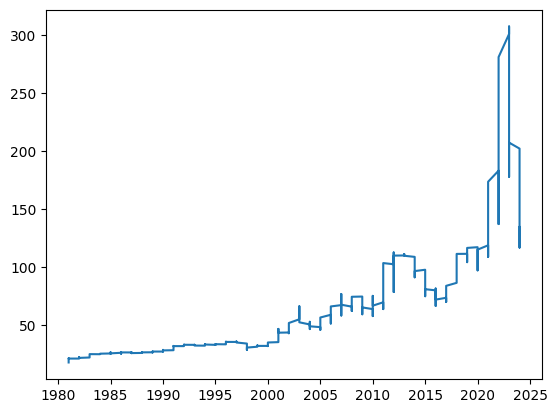

In [11]:
plt.plot(df_clean['REF_DATE'].dt.to_timestamp(), df_clean['VALUE_SMOOTH'])


In [12]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [ ]:
data = df_clean['VALUE_SMOOTH'].values.reshape(-1, 1)

scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [61]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = torch.FloatTensor(data)
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length]
        return x, y

SEQ_LENGTH = 5
dataset = TimeSeriesDataset(data_normalized, SEQ_LENGTH)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [64]:

for batch_x, batch_y in train_loader:
    
    print(f"batch_x shape: {batch_x.shape}")  # Should be (batch_size, seq_length, 1)
    print(f"batch_y shape: {batch_y.shape}")  # Should be (batch_size, 1)
    
    # break  # Just print one batch


batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape: torch.Size([16, 1])
batch_x shape: torch.Size([16, 5, 1])
batch_y shape

In [65]:
#MODEL TIME
class LSTMModel(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1, num_layers=1):
        super().__init__()
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
       
        lstm_out, _ = self.lstm(x)  # lstm_out: (batch_size, seq_length, hidden_size)
        predictions = self.linear(lstm_out[:, -1, :])  # Use last timestep
        return predictions

model = LSTMModel()
model

LSTMModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [70]:
# Loss and optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 200

# Training
for epoch in range(epochs):
    model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        outputs = model(batch_x)  # Add input_size dimension
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            outputs = model(batch_x)
            test_loss += criterion(outputs, batch_y.unsqueeze(-1)).item()
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss/len(test_loader):.4f}")

/home/jun/.local/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/jun/.local/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([3, 1, 1])) that is different to the input size (torch.Size([3, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/200 | Train Loss: 0.0014 | Test Loss: 0.0396
Epoch 2/200 | Train Loss: 0.0001 | Test Loss: 0.0388
Epoch 3/200 | Train Loss: 0.0001 | Test Loss: 0.0405
Epoch 4/200 | Train Loss: 0.0032 | Test Loss: 0.0438
Epoch 5/200 | Train Loss: 0.0004 | Test Loss: 0.0428
Epoch 6/200 | Train Loss: 0.0004 | Test Loss: 0.0437
Epoch 7/200 | Train Loss: 0.0003 | Test Loss: 0.0375
Epoch 8/200 | Train Loss: 0.0004 | Test Loss: 0.0443
Epoch 9/200 | Train Loss: 0.0001 | Test Loss: 0.0434
Epoch 10/200 | Train Loss: 0.0015 | Test Loss: 0.0440
Epoch 11/200 | Train Loss: 0.0003 | Test Loss: 0.0423
Epoch 12/200 | Train Loss: 0.0012 | Test Loss: 0.0437
Epoch 13/200 | Train Loss: 0.0001 | Test Loss: 0.0420
Epoch 14/200 | Train Loss: 0.0003 | Test Loss: 0.0423
Epoch 15/200 | Train Loss: 0.0061 | Test Loss: 0.0415
Epoch 16/200 | Train Loss: 0.0010 | Test Loss: 0.0383
Epoch 17/200 | Train Loss: 0.0001 | Test Loss: 0.0434
Epoch 18/200 | Train Loss: 0.0000 | Test Loss: 0.0422
Epoch 19/200 | Train Loss: 0.0002 | T

/tmp/ipykernel_9214/1188180831.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date, periods=FUTURE_STEPS, freq='M')  # 12 months ahead


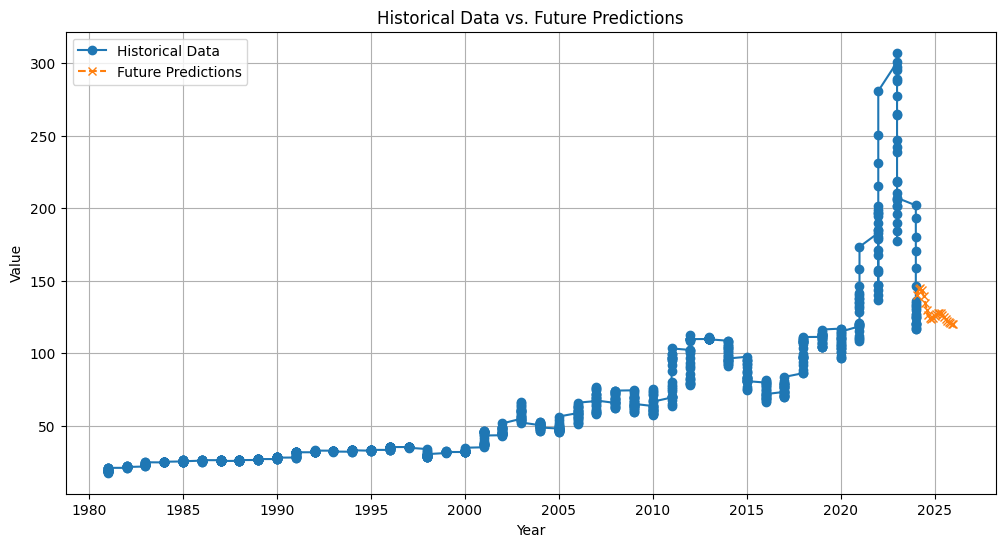

In [86]:
import matplotlib.pyplot as plt
import numpy as np
# Function to predict future values recursively
def predict_future(model, data, seq_length, future_steps):
    model.eval()
    predictions = []
    last_sequence = data[-seq_length:]  # Shape: (seq_length, 1) if data is 2D
    
    for _ in range(future_steps):
        with torch.no_grad():
            # Fix: Remove extra unsqueeze(-1)
            x = torch.FloatTensor(last_sequence).unsqueeze(0)  # Correct shape: [1, seq_length, 1]
            pred = model(x)
            predictions.append(pred.item())
            last_sequence = np.append(last_sequence[1:], pred.item()).reshape(-1, 1)  # Ensure 2D shape
    
    return predictions

# Predict future values (e.g., 5 years beyond 2025)
FUTURE_STEPS = 24
future_predictions = predict_future(model, data_normalized, SEQ_LENGTH, FUTURE_STEPS)

# Inverse scaling for all data
actuals = scaler.inverse_transform(data_normalized)
predictions_future = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create time indices
#historical_years = df.index.values  # 1980–2025
last_date = df_clean['REF_DATE'].dt.to_timestamp().max()  # Get latest date
future_dates = pd.date_range(start=last_date, periods=FUTURE_STEPS, freq='M')  # 12 months ahead


# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_clean['REF_DATE'].dt.to_timestamp(), actuals, label="Historical Data", marker='o')
plt.plot(future_dates, predictions_future, label="Future Predictions", marker='x', linestyle='--')
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Historical Data vs. Future Predictions")
plt.legend()
plt.grid(True)
plt.show()